<a href="https://colab.research.google.com/github/Saharochek98/Statistics-of-Stochastic-Processes/blob/main/SSP_Lab1_2026_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
from matplotlib import pyplot as plt

Task 1. Simulate a path of the Wiener process. Number of end-points of the grid including $T$ is $N=100$, length of the interval $[0, T]$ in time units is 1, time increment is $\Delta = T/N$. Plot the path.

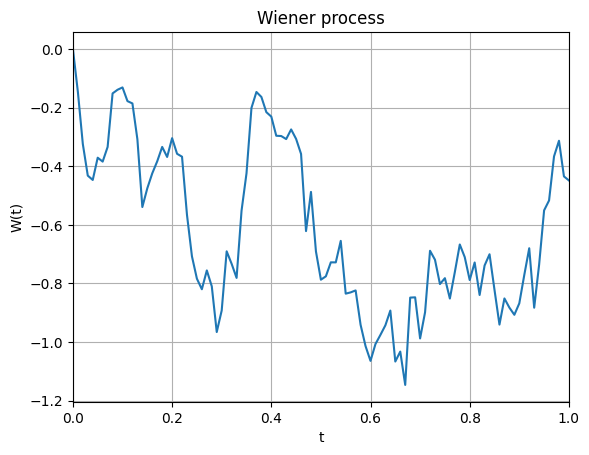

In [2]:
def WienerRandomValue(t):
    return np.sqrt(t) * np.random.normal(0, 1)


def WienerProcess(N, T):
    t_data = np.linspace(0, T, N + 1)
    w_data = np.zeros(N + 1)
    dt = T/N
    for i in range(1, N + 1):
        w_data[i] = w_data[i - 1] + WienerRandomValue(dt)
    return t_data, w_data

N = 100
T = 1
t_data, w_data = WienerProcess(N, T)

plt.plot(t_data, w_data)
plt.xlabel("t")
plt.ylabel("W(t)")
plt.xlim(0.0, T)
plt.title("Wiener process")
plt.grid(True)
plt.show()

Task 2. Using the random walk algorithm simulate three paths of the Wiener process as the limit of a random walk for different $n=10, 100, 1000$. Plot the paths in one figure, add the legend.

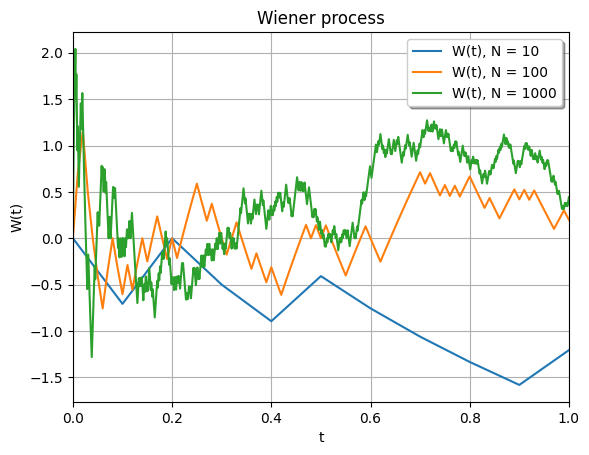

In [3]:
def RandomValueP(p):
    assert p > 0.0 and p < 1.0, '0 < p < 1'

    rand = np.random.uniform(0, 1)
    if rand <= p:
        return 1
    else:
        return -1

def RandomWalk(p, N):
    t_data = np.linspace(0, 1, N + 1)
    w_data = np.zeros(N + 1)
    for i in range(1, N + 1):
        w_data[i] = w_data[i - 1] * np.sqrt(i / (i + 1)) + RandomValueP(p) / np.sqrt(i + 1)
    return t_data, w_data

p = 0.5
N = [10, 100, 1000]
for k in N:
    t_data, w_data = RandomWalk(p, k)
    plt.plot(t_data, w_data, label = f"W(t), N = {k}")

plt.legend(loc = 'best', fancybox = True, shadow = True)
plt.xlim(0.0, 1.0)
plt.xlabel("t")
plt.ylabel("W(t)")
plt.title("Wiener process")
plt.grid(True)
plt.show()

Task 3. Using the the Karhunen-Loeve expansion simulate three paths of the Wiener process with
$n = 10, 50, 100$ terms. Plot the paths in one figure, add legends.

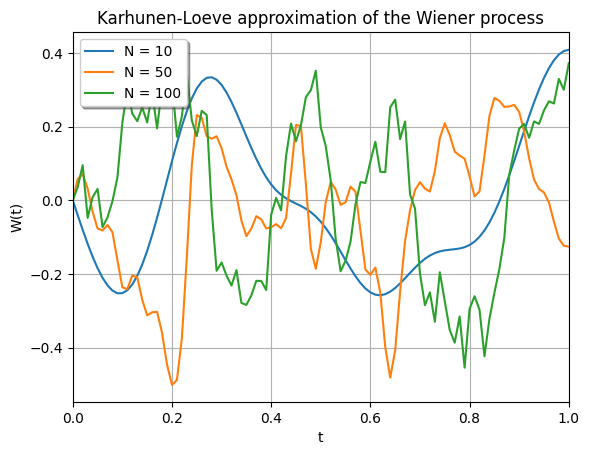

In [4]:
def phi(k, t, T):
    return 2 * np.sqrt(2 * T) / np.pi / (2 * k + 1) * np.sin((2 * k + 1) * np.pi * t / (2 * T))

def KarhunenLoeveApprox(T, Nt, Nz):
    z_data = np.random.normal(0, 1, size = Nz)
    t_data = np.linspace(0, T, Nt + 1)
    k = np.arange(0, len(z_data)) + 1
    w_data = np.zeros(Nt + 1)
    for i in range(0, Nt + 1):
        phi_data = phi(k, t_data[i], T)
        w_data[i] = np.dot(z_data, phi_data)
    return t_data, w_data

T = 1
Nt = 100
Nz = [10, 50, 100]

for k in Nz:
    t_data, w_data = KarhunenLoeveApprox(T, Nt, k)
    plt.plot(t_data, w_data, label = f'N = {k}')

plt.legend(loc = 'upper left', fancybox = True, shadow = True)
plt.xlim(0.0, 1.0)
plt.xlabel("t")
plt.ylabel("W(t)")
plt.title("Karhunen-Loeve approximation of the Wiener process")
plt.grid(True)
plt.show()

Task 4. Plot a trajectory of the geometric Brownian motion obtained from the simulation of the path of the Wiener process, $r=1$ (interest rate) and $\sigma = 0.5$ (volatility).

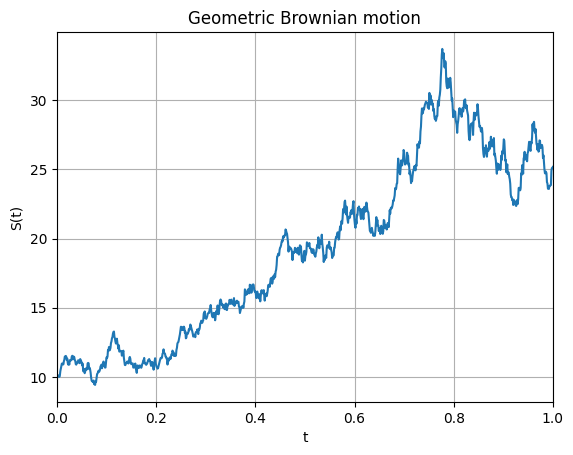

In [5]:
def GeometricBrownianMotion(S0, r, sigma, T):
    Nt = 1000
    t_data = np.linspace(0, T, Nt + 1)
    s_data = np.zeros(Nt + 1)
    s_data[0] = S0
    dt = T / Nt
    for i in range(1, Nt + 1):
        s_data[i] = s_data[i-1] * np.exp((r - sigma**2 / 2)* dt + sigma * WienerRandomValue(dt))
    return t_data, s_data

S0 = 10
r = 1
sigma = 0.5
T = 1

t_data, s_data = GeometricBrownianMotion(S0, r, sigma, T)
plt.plot(t_data, s_data)
plt.xlim(0.0, 1.0)
plt.xlabel("t")
plt.ylabel("S(t)")
plt.title("Geometric Brownian motion")
plt.grid(True)
plt.show()

Task 5. Plot a trajectory of the the Brownian bridge starting at $x$ at time $0$ and terminating its run at $y =-1$ at time $T$ obtained from the simulation of the path of the Wiener process. Add markers for start and end points.

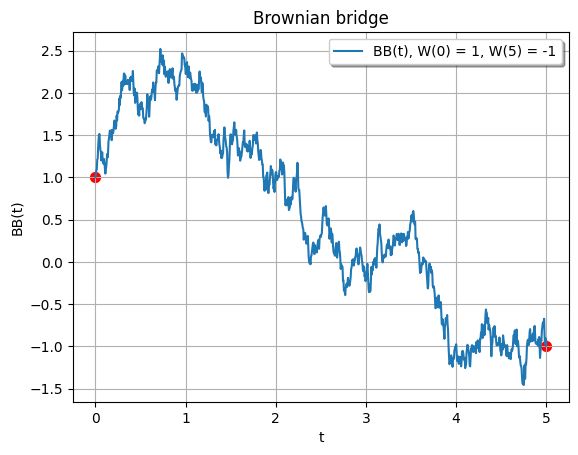

In [6]:
def BrownianBridge(x, y, t0, T):
    Nt = 1000
    t_data, w_data = WienerProcess(Nt, T)
    dt = T/Nt
    bb_data = np.zeros(Nt + 1)
    for i in range(0, Nt + 1):
        bb_data[i] = x + w_data[i] - (t_data[i] - t0) / (T - t0) * (w_data[(Nt - 1)-t0] - y + x)
    return t_data, bb_data

x = 1
y = -1
t0 = 0
T = 5
t_data, bb_data = BrownianBridge(x, y, t0, T)

plt.plot(t_data, bb_data, label = f"BB(t), W({t0}) = {x}, W({T}) = {y}")
plt.scatter ( t0, x, color = "red", s = 50)
plt.scatter ( T, y, color = "red", s = 50)
plt.legend(loc = 'best', fancybox = True, shadow = True)
plt.xlabel("t")
plt.ylabel("BB(t)")
plt.title("Brownian bridge")
plt.grid(True)
plt.show()

# Exercises

Exercise 1. Let us consider a random walk $X = (X_n)_{n \geq 0}$:
$$
X_n = \sum_{k=1}^n \xi_k, \quad \xi_k =
\begin{cases}
1, &\text{with probability $\frac12$}; \\
-1, &\text{with probability $\frac12$}.
\end{cases}
$$
$$
\mathbb{E}\xi_k = 0, \quad \mathrm{Var}\, \xi_k = 1.
$$

Plot $(X_{t_i})_{t_i = \frac{i}{n}}$ so that $t_i$ takes values in $[0,\, 1]$.

In [7]:
def RandomWalk(N, p=[0.5, 0.5]):
    # Генерируем случайные шаги
    xi = np.random.choice([-1, 1], size=N, p=p)

    # Вычисляем случайное блуждание
    X = np.cumsum(xi)  # Кумулятивная сумма шагов

    # Добавляем начальную позицию (0)
    X = np.insert(X, 0, 0)  # Добавляем X_0 = 0 в начало

    # Создаем массив t
    t = np.linspace(0, 1, N + 1)  # n + 1 точек для t_i

    # Строим график
    plt.figure(figsize=(10, 5))
    plt.plot(t, X, marker='o', linestyle='-')
    plt.title('Random Walk')
    plt.xlabel('t')
    plt.ylabel('$X_n$')
    plt.grid()
    plt.show()

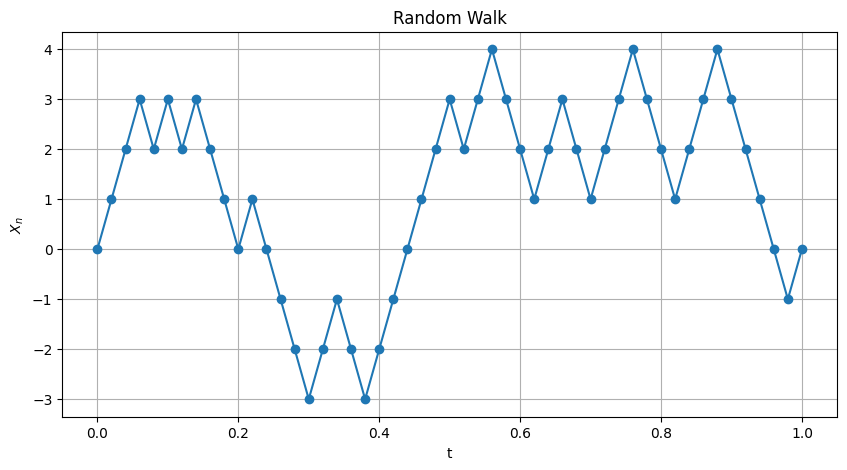

In [8]:
RandomWalk(N=50)

Exercise 2. Let $H = (H_n)_{n \geq 1}$ be the player's bet at the $n$-th step, i.e. his winnings at this step are equal to $H_n (X_n - X_{n-1}) = H_n \Delta X_n$.

Plot an accumulated winnings of player $Y_n$ at step $n \geq 1$.


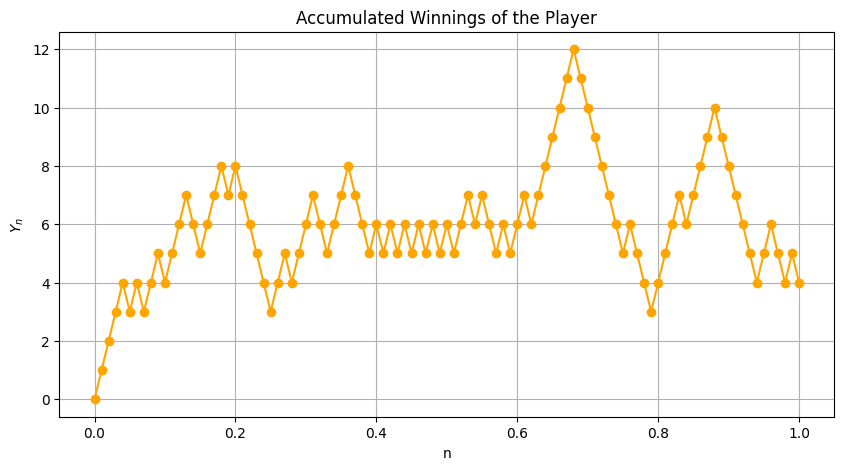

In [9]:
def random_walk_with_bets(n, H):
    # Генерируем случайные шаги
    xi = np.random.choice([-1, 1], size=n, p=[0.5, 0.5])

    # Вычисляем случайное блуждание
    X = np.cumsum(xi)

    # Добавляем начальную позицию (0)
    X = np.insert(X, 0, 0)  # Добавляем X_0 = 0 в начало

    # Вычисляем накопленные выигрыши
    Y = np.zeros(n + 1)  # Начинаем с 0
    for i in range(1, n + 1):
        Y[i] = Y[i - 1] + H * (X[i] - X[i - 1])  # Y_n = Y_{n-1} + H * ΔX_n

    # Создаем массив t
    t = np.linspace(0, 1, n + 1)  # n + 1 точек для t_i

    # Строим график накопленных выигрышей
    plt.figure(figsize=(10, 5))
    plt.plot(t, Y, marker='o', linestyle='-', color='orange')
    plt.title('Accumulated Winnings of the Player')
    plt.xlabel('n')
    plt.ylabel('$Y_n$')
    plt.grid()
    plt.show()

# Пример вызова функции с n = 100 и H = 1
random_walk_with_bets(100, H=1)

# Задачи

Задача 1. Квадратичная вариация (Раздел 1.1.2)

Для траектории винеровского процесса при $T=1$ и разного числа интервалов разбиения $\{10,100,1000,10000\}$:

1. Вычислите сумму квадратов приращений $$ S_n= ∑_{k=0}^{n−1}​ ∣W(t_{k+1} )−W(t_k​ )∣^2.$$

2. Постройте график зависимости суммы $S_n$ от числа интервалов разбиения (столбчатую диаграмму).

3. Сделайте выводы.

N = 10 ; S_n = 0.671
N = 100 ; S_n = 0.828
N = 1000 ; S_n = 0.982
N = 10000 ; S_n = 1.003


/tmp/ipykernel_152/415409385.py:37: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


<Figure size 1000x800 with 0 Axes>

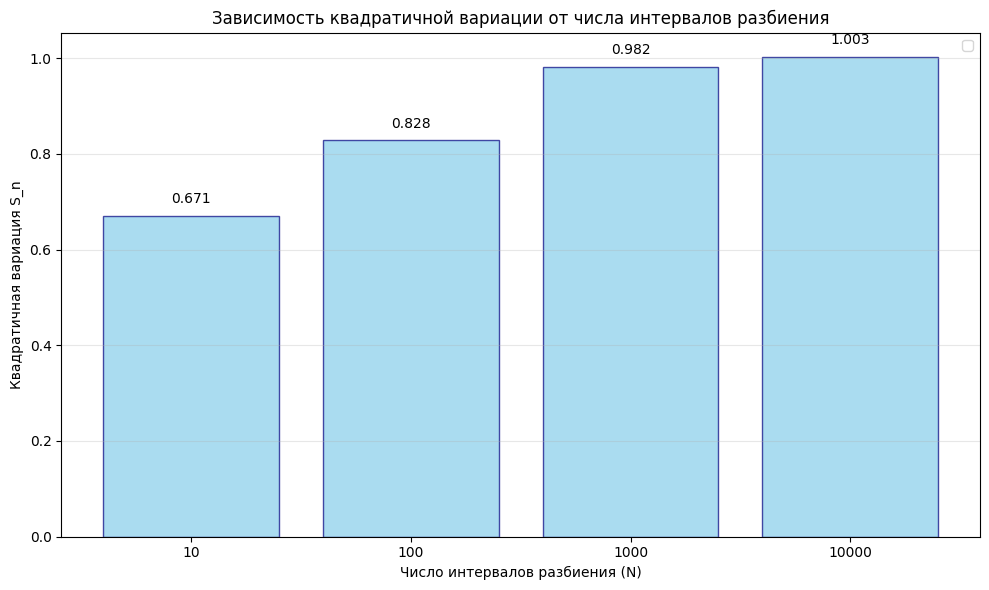

In [10]:
def quadratic_variation(w):
    """Вычисляет квадратичную вариацию"""
    increments = np.diff(w)
    S = np.sum(increments**2)
    return S

N = [10, 100, 1000, 10000]
T = 1
np.random.seed(42)
S_values = []

plt.figure(figsize=(10, 8))
results = {}

for k in N:
    t_data, w_data = WienerProcess(k, T)
    S = quadratic_variation(w_data)
    S_values.append(S)
    print(f"N = {k} ; S_n = {S:.3f}")

# Построение столбчатой диаграммы
plt.figure(figsize=(10, 6))
bars = plt.bar(range(len(N)), S_values, tick_label=N, color='skyblue', edgecolor='navy', alpha=0.7)

# Добавление значений над столбцами
for i, (bar, val) in enumerate(zip(bars, S_values)):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.02,
             f'{val:.3f}', ha='center', va='bottom', fontsize=10)

# Настройка графика
plt.title('Зависимость квадратичной вариации от числа интервалов разбиения', fontsize=12)
plt.xlabel('Число интервалов разбиения (N)', fontsize=10)
plt.ylabel('Квадратичная вариация S_n', fontsize=10)
plt.xticks(range(len(N)), N)
plt.grid(True, alpha=0.3, axis='y')
plt.legend()

plt.tight_layout()
plt.show()


### Вывод:

При увеличении числа интервалов разбиения N,
квадратичная вариация S_n стремится к 1 (T=1)/
Это фундаментальное свойство винеровского процесса


Задача 2. Эмпирическая ковариационная функция (Раздел 1.1.3)

Для винеровского процесса теоретическая ковариация между состояниями в моменты времени $s$ и $t$ равна $\min(s,t)$.

1. Сгенерируйте ансамбль из 500 траекторий винеровского процесса.

2. Вычислите выборочную ковариацию между точками $t=0.5$ и $t=T$ и сравните полученное число с теоретическим значением $0.5$.

3. Сделайте выводы.

In [11]:
N_traj= 500
N = 1000
T = 1
t1 = 0.5
t2 = T

np.random.seed(42)
W_t1_values = []
W_t2_values = []

for i in range(N_traj):
    t, W = WienerProcess(N, T)

    idx_t1 = int(t1 * N)  # t=0.5
    idx_t2 = -1  #t=1

    W_t1_values.append(W[idx_t1])
    W_t2_values.append(W[idx_t2])

W_t1_values = np.array(W_t1_values)
W_t2_values = np.array(W_t2_values)

theoretical_cov = min(t1, t2)
empirical_cov = np.cov(W_t1_values, W_t2_values)[0, 1]
empirical_corr = np.corrcoef(W_t1_values, W_t2_values)[0, 1]

print(f"Теоретическая ковариация Cov(W(0.5), W(1)) = min(0.5, 1) = {theoretical_cov}")
print(f"Эмпирическая ковариация (по {N_traj} траекториям): {empirical_cov:.3f}")
print(f"Относительная ошибка: {abs(empirical_cov - theoretical_cov)/theoretical_cov*100:.3f}%")

Теоретическая ковариация Cov(W(0.5), W(1)) = min(0.5, 1) = 0.5
Эмпирическая ковариация (по 500 траекториям): 0.535
Относительная ошибка: 6.904%


### Вывод:
Эмпирическая ковариация, вычисленная по ансамблю траекторий, близка к теоретическому значению min(0.5, 1) = 0.5

Это демонстрирует, что винеровский процесс обладает свойством Cov(W(s), W(t)) = min(s, t)

С увеличением числа траекторий точность оценки растет

Задача 3. Тестирование мартингального свойства (Раздел 1.1.5)

1. Сгенерируйте ансамбль из 500 траекторий винеровского процесса.

2. Выберите фиксированный момент времени $s=0.4$.

3. Для всех сгенерированных траекторий, проходящих через определенный узкий диапазон значений в момент $s$, вычислите среднее арифметическое их значений в финальный момент $T$.

4. Сравните полученное среднее арифметическое со значением процесса в момент $s$.

5. Сделайте выводы. Проанализовать как диапозон влияет на результат.


Диапазон Δ = 0.2
Границы диапазона: [-0.109, 0.091]
Количество траекторий в диапазоне: 66 из 500


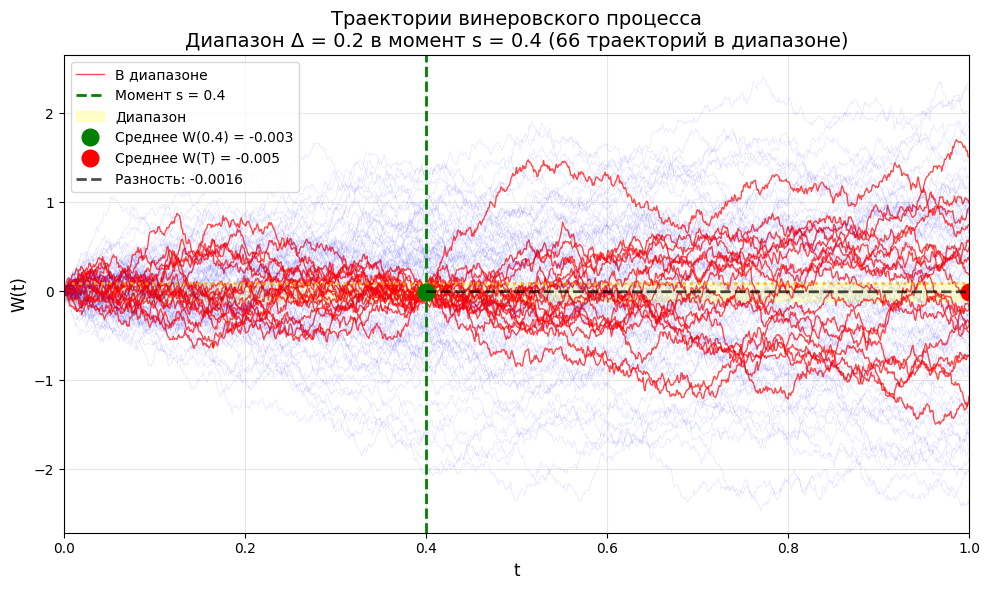

Среднее W(0.4) в диапазоне: -0.0032
Среднее W(T) для выбранных траекторий: -0.0049
Разность (отклонение от мартингала): -0.0016
Мартингальное свойство подтверждается (отклонение в пределах статистической погрешности)


In [12]:
N_traj = 500
N = 1000
T = 1
s = 0.4
delta = 0.2

np.random.seed(42)

all_trajectories = []
W_s_values = []
W_T_values = []

for i in range(N_traj):
    t, W = WienerProcess(N, T)
    all_trajectories.append((t, W))

    idx_s = int(s * N)
    W_s_values.append(W[idx_s])
    W_T_values.append(W[-1])

W_s_values = np.array(W_s_values)
W_T_values = np.array(W_T_values)

center = np.mean(W_s_values)
lower_bound = center - delta/2
upper_bound = center + delta/2

mask = (W_s_values >= lower_bound) & (W_s_values <= upper_bound)
selected_indices = np.where(mask)[0]
n_selected = len(selected_indices)

print(f"\nДиапазон Δ = {delta}")
print(f"Границы диапазона: [{lower_bound:.3f}, {upper_bound:.3f}]")
print(f"Количество траекторий в диапазоне: {n_selected} из {N_traj}")

if n_selected > 0:
    mean_W_T = np.mean(W_T_values[mask])
    mean_W_s = np.mean(W_s_values[mask])


    plt.figure(figsize=(10, 6))

    for i, (t_i, W_i) in enumerate(all_trajectories):
        if i < 100:
            if mask[i]:  # Выбранные - красным
                plt.plot(t_i, W_i, 'r-', alpha=0.7, linewidth=1.0, label='В диапазоне' if i == selected_indices[0] else "")
            else:  # Остальные - синим
                plt.plot(t_i, W_i, 'b-', alpha=0.1, linewidth=0.5)

    # Отмечаем момент s и диапазон
    plt.axvline(x=s, color='green', linestyle='--', linewidth=2, label=f'Момент s = {s}')
    plt.axhline(y=upper_bound, color='orange', linestyle=':', linewidth=2, alpha=0.8)
    plt.fill_between([0, T], lower_bound, upper_bound, color='yellow', alpha=0.2, label=f'Диапазон')

    plt.plot(s, mean_W_s, 'go', markersize=12, label=f'Среднее W({s}) = {mean_W_s:.3f}')
    plt.plot(T, mean_W_T, 'ro', markersize=12, label=f'Среднее W(T) = {mean_W_T:.3f}')

    plt.plot([s, T], [mean_W_s, mean_W_T], 'k--', linewidth=2, alpha=0.7, label=f'Разность: {mean_W_T - mean_W_s:.4f}')

    plt.xlabel('t', fontsize=12)
    plt.ylabel('W(t)', fontsize=12)
    plt.title(f'Траектории винеровского процесса\nДиапазон Δ = {delta} в момент s = {s} ({n_selected} траекторий в диапазоне)', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.legend(loc='upper left', fontsize=10)
    plt.xlim(0, T)

    plt.tight_layout()
    plt.show()


    print(f"Среднее W({s}) в диапазоне: {mean_W_s:.4f}")
    print(f"Среднее W(T) для выбранных траекторий: {mean_W_T:.4f}")
    print(f"Разность (отклонение от мартингала): {mean_W_T - mean_W_s:.4f}")

    if abs(mean_W_T - mean_W_s) < 0.05:
        print("Мартингальное свойство подтверждается (отклонение в пределах статистической погрешности)")
    else:
        print("Отклонение от мартингального свойства превышает ожидаемую статистическую погрешность")


### Вывод:

Проверка мартингального свойства:
   Для винеровского процесса мартингальное свойство означает:
   E[W(T) | F_s] = W(s), где F_s - информация до момента s.
   
   В нашем эксперименте мы проверяли: E[W(T) | W(s) ∈ [a,b]] ≈ среднее W(s) в этом диапазоне.

Задача 4. Анализ независимости приращений (Раздел 1.2)

1. Выберите два непересекающихся интервала $[t_1, t_2​]$ и $[t_3, t_4​]$.
2. Сгенерируйте $M$ траекторий и вычислите приращения
$ΔW_1 =W(t_2)−W(t_1)$ и $ΔW_2 =W(t_4)−W(t_3)$.

3. Постройте диаграмму рассеяния (scatter plot) для $(ΔW_1, ΔW_2)$ и вычислите коэффициент корреляции.

4. Сравните полученное значение с нулем и сделайте выводы.

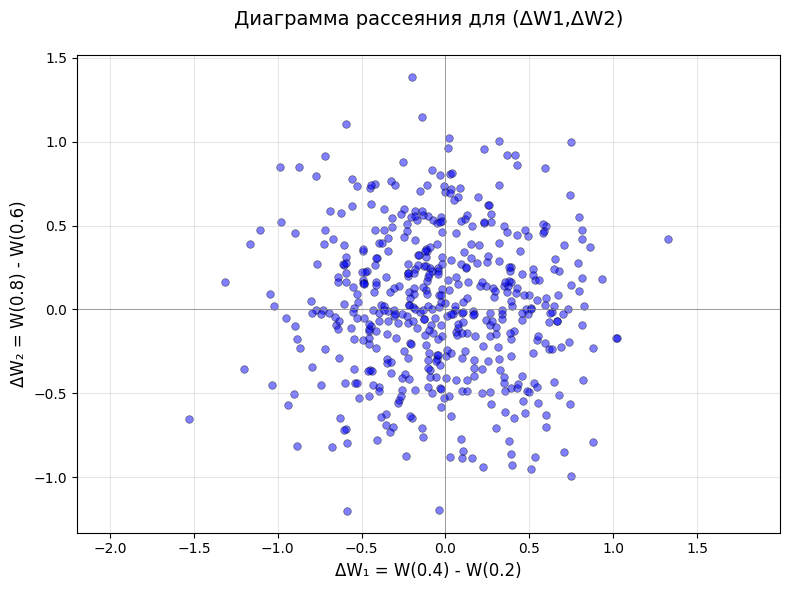

Ин-л 1: [0.2, 0.4]
Ин-л 2: [0.6, 0.8]
[[ 1.         -0.02961261]
 [-0.02961261  1.        ]]
Среднее значение ΔW₁: -0.0357 (теор 0)
Среднее значение ΔW₂: 0.0249 (теор 0)
Дисперсия ΔW₁: 0.2037 (теор 0.20)
Дисперсия ΔW₂: 0.1899 (теор0.20)


In [13]:
M = 500
N = 1000
T = 1

t1, t2 = 0.2, 0.4
t3, t4 = 0.6, 0.8

np.random.seed(42)

delta_W1 = []
delta_W2 = []

for i in range(M):
    t, W = WienerProcess(N, T)

    idx_t1 = int(t1 * N)
    idx_t2 = int(t2 * N)
    idx_t3 = int(t3 * N)
    idx_t4 = int(t4 * N)

    dW1 = W[idx_t2] - W[idx_t1]
    dW2 = W[idx_t4] - W[idx_t3]

    delta_W1.append(dW1)
    delta_W2.append(dW2)

delta_W1 = np.array(delta_W1)
delta_W2 = np.array(delta_W2)

correlation = np.corrcoef(delta_W1, delta_W2)

plt.figure(figsize=(8, 6))
plt.scatter(delta_W1, delta_W2, alpha=0.5, s=30, c='blue', edgecolors='black', linewidth=0.5)
plt.xlabel(f'ΔW₁ = W({t2}) - W({t1})', fontsize=12)
plt.ylabel(f'ΔW₂ = W({t4}) - W({t3})', fontsize=12)
plt.title(f'Диаграмма рассеяния для (ΔW1,ΔW2)\n', fontsize=14)
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='gray', linestyle='-', linewidth=0.5)
plt.axvline(x=0, color='gray', linestyle='-', linewidth=0.5)
plt.axis('equal')

plt.tight_layout()
plt.show()

print(f"Ин-л 1: [{t1}, {t2}]")
print(f"Ин-л 2: [{t3}, {t4}]")
print(correlation)
print(f"Среднее значение ΔW₁: {np.mean(delta_W1):.4f} (теор 0)")
print(f"Среднее значение ΔW₂: {np.mean(delta_W2):.4f} (теор 0)")
print(f"Дисперсия ΔW₁: {np.var(delta_W1):.4f} (теор {t2-t1:.2f})")
print(f"Дисперсия ΔW₂: {np.var(delta_W2):.4f} (теор{t4-t3:.2f})")


### Вывод
Корреляция близка к нулю, что подтверждает независимость приращений винеровского процесса на непересекающихся интервалах

Задача 5. Точность разложения Карунена-Лоэва (Раздел 1.2.3)

1. Реализуйте аппроксимацию винеровской траектории, используя $n=10, 100, 1000$ слагаемых.
2. Рассчитайте среднеквадратичную ошибку между прямой симуляцией и аппроксимацией Карунена-Лоэва.

3. Постройте график зависимости ошибки при увеличении числа членов ряда $n$.
4. Сделайте выводы.


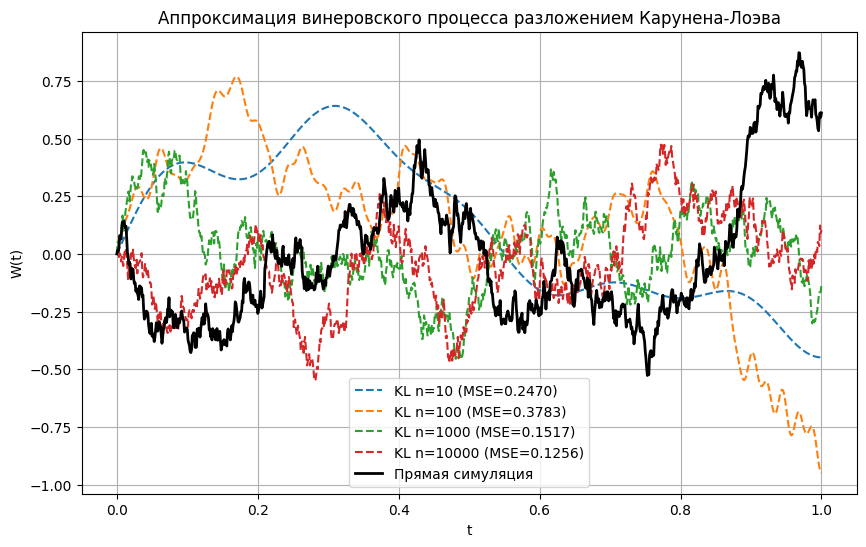

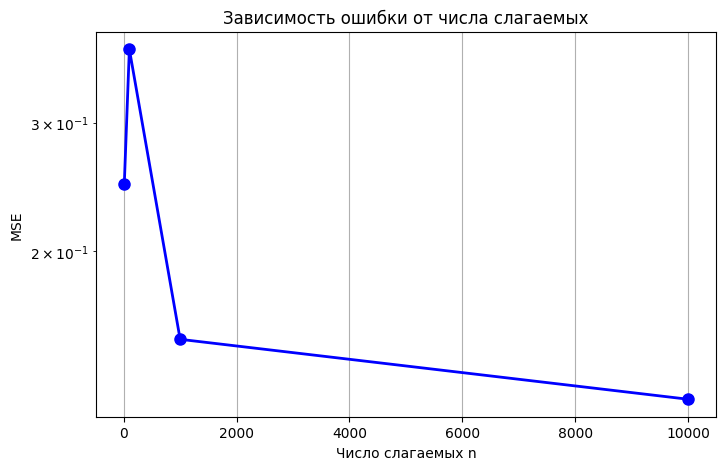

Ошибки при разных n:
n = 10: MSE = 0.247040
n = 100: MSE = 0.378296
n = 1000: MSE = 0.151652
n = 10000: MSE = 0.125565


In [14]:
T = 1
Nt = 1000
n_values = [10, 100, 1000, 10000]
errors = []
np.random.seed(42)

t_ref, w_ref = WienerProcess(Nt, T)
plt.figure(figsize=(10, 6))

for n in n_values:
    t_kl, w_kl = KarhunenLoeveApprox(T, Nt, n)
    mse = np.mean((w_ref - w_kl) ** 2)
    errors.append(mse)
    plt.plot(t_kl, w_kl, '--', label=f'KL n={n} (MSE={mse:.4f})')

plt.plot(t_ref, w_ref, 'k-', linewidth=2, label='Прямая симуляция')

plt.xlabel('t')
plt.ylabel('W(t)')
plt.title('Аппроксимация винеровского процесса разложением Карунена-Лоэва')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.semilogy(n_values, errors, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Число слагаемых n')
plt.ylabel('MSE')
plt.title('Зависимость ошибки от числа слагаемых')
plt.grid(True)
plt.show()

print("Ошибки при разных n:")
for n, err in zip(n_values, errors):
    print(f"n = {n}: MSE = {err:.6f}")